<a href="https://colab.research.google.com/github/goureshvaishnav/CT-Assessment/blob/main/Week5_Gouresh_Vaishnav.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


#  Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)


input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

Vocabulary Size: 37
X Shape: (35, 7)
y Shape: (35,)


 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

def build_rnn():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        SimpleRNN(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
rnn_model = build_rnn()

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.0286 - loss: 3.6046
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1143 - loss: 3.5261
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2571 - loss: 3.4720
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2857 - loss: 3.4215
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2857 - loss: 3.3785
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2571 - loss: 3.3312
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2857 - loss: 3.2828
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3143 - loss: 3.2317
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3143 - loss: 3.1828
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3429 - loss: 3.1250
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2857 - loss: 3.0751
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2857 - loss: 3.0206
E

#  Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

def build_lstm():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        LSTM(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
print("\nTraining LSTM...\n")

lstm_model = build_lstm()

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

print("\nLSTM Training Complete\n")


Training LSTM...

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.0000e+00 - loss: 3.6133
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1143 - loss: 3.6045
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1143 - loss: 3.5984
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0571 - loss: 3.5928
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0286 - loss: 3.5875
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5811
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0571 - loss: 3.5747
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1143 - loss: 3.5677
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0857 - loss: 3.5596
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0857 - loss: 3.5508
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.0857 - loss: 3.5402
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step 

# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

def build_gru():

    model = Sequential([
        Embedding(total_words, 64, input_length=max_len-1),
        GRU(128),
        Dense(total_words, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [9]:
print("\nTraining GRU...\n")

gru_model = build_gru()

gru_history = gru_model.fit(
    X,
    y,
    epochs=150,
    verbose=1
)

print("\nGRU Training Complete\n")


Training GRU...

Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.0286 - loss: 3.6096
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1429 - loss: 3.5969
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 - loss: 3.5871
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1714 - loss: 3.5783
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2000 - loss: 3.5692
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2000 - loss: 3.5600
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2286 - loss: 3.5505
Epoch 8/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2286 - loss: 3.5398
Epoch 9/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2571 - loss: 3.5284
Epoch 10/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3143 - loss: 3.5158
Epoch 11/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2571 - loss: 3.5012
Epoch 12/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc

#Compare Training Loss

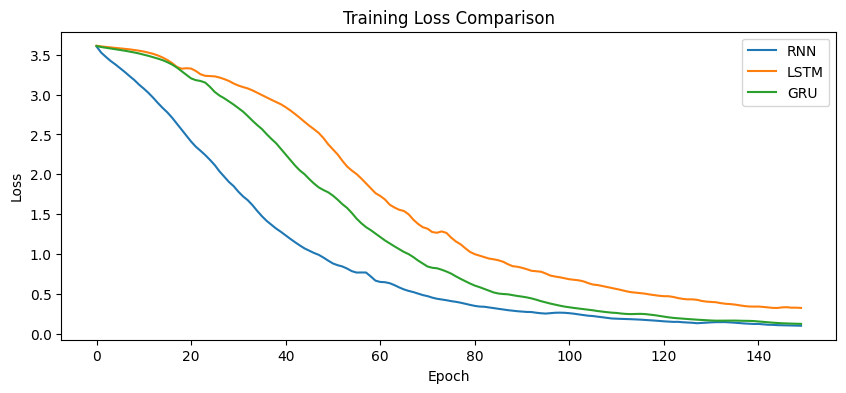

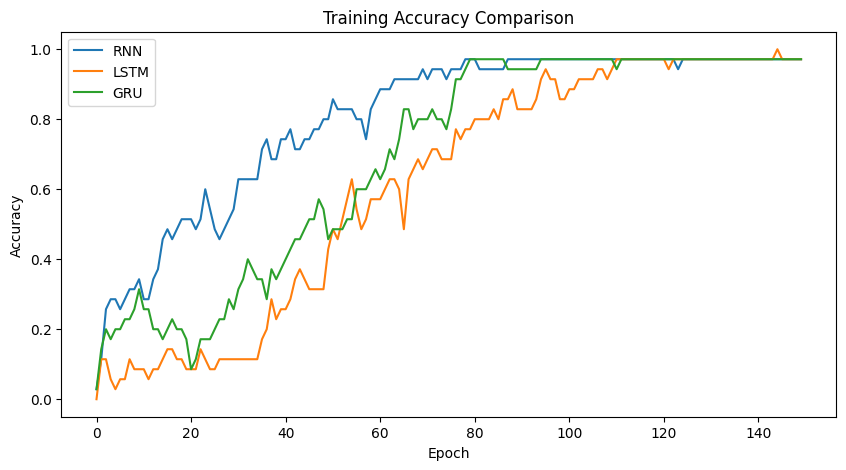

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=8):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

**Generate Text Samples**

In [12]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is transforming artificial intelligence sentences
GRU : deep learning is transforming artificial intelligence intelligence


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**